# **Cuaderno 5.1: Pérdida por mínimos cuadrados**

Este cuaderno investiga la pérdida por mínimos cuadrados y la equivalencia entre la máxima verosimilitud y la mínima log-verosimilitud negativa.

Trabaje a través de las celdas a continuación, ejecutando cada una a su vez. En varios lugares verá las palabras 'TO DO'. Siga las instrucciones en estos lugares y haga predicciones sobre lo que sucederá o escriba código para completar las funciones.

Contácteme en udlbookmail@gmail.com si encuentra algún error o tiene alguna sugerencia.

In [1]:
# Importa la librería math
import numpy as np
# Importa la librería de trazado
import matplotlib.pyplot as plt
# Importa la librería math
import math

In [2]:
# Define la ReLU
def ReLU(preactivation):
  activation = preactivation.clip(0.0)
  return activation

# Define una shallow neural network
def shallow_nn(x, beta_0, omega_0, beta_1, omega_1):
    # Make sure that input data is (1 x n_data) array
    n_data = x.size
    x = np.reshape(x,(1,n_data))

    # Ejecuta la red para todos los inputs simultaneos
    h1 = ReLU(np.matmul(beta_0,np.ones((1,n_data))) + np.matmul(omega_0,x))
    y = np.matmul(beta_1,np.ones((1,n_data))) + np.matmul(omega_1,h1)
    return y

In [3]:
# Obtener parámetros para el modelo: podemos llamar a esta función para restablecerlos fácilmente
def get_parameters():
  # Y crearemos una red que se ajuste aproximadamente
  beta_0 = np.zeros((3,1));  # anteriormente theta_x0
  omega_0 = np.zeros((3,1)); # anteriormente theta_x1
  beta_1 = np.zeros((1,1));  # anteriormente phi_0
  omega_1 = np.zeros((1,3)); # anteriormente phi_x

  beta_0[0,0] = 0.3; beta_0[1,0] = -1.0; beta_0[2,0] = -0.5
  omega_0[0,0] = -1.0; omega_0[1,0] = 1.8; omega_0[2,0] = 0.65
  beta_1[0,0] = 0.1;
  omega_1[0,0] = -2.0; omega_1[0,1] = -1.0; omega_1[0,2] = 7.0

  return beta_0, omega_0, beta_1, omega_1

In [4]:
# Función de utilidad para trazar datos
def plot_univariate_regression(x_model, y_model, x_data = None, y_data = None, sigma_model = None, title= None):
  # Asegurarse de que los datos del modelo sean arreglos 1D
  x_model = np.squeeze(x_model)
  y_model = np.squeeze(y_model)

  fig, ax = plt.subplots()
  ax.plot(x_model,y_model)
  if sigma_model is not None:
    ax.fill_between(x_model, y_model-2*sigma_model, y_model+2*sigma_model, color='lightgray')
  ax.set_xlabel('Entrada, $x$'); ax.set_ylabel('Salida, $y$')
  ax.set_xlim([0,1]);ax.set_ylim([-1,1])
  ax.set_aspect(0.5)
  if title is not None:
    ax.set_title(title)
  if x_data is not None:
    ax.plot(x_data, y_data, 'ko')
  plt.show()

# Regresión univariada

Investigaremos una situación de regresión univariada simple con una única entrada $x$ y una única salida $y$, como se muestra en las figuras 5.4 y 5.5b.

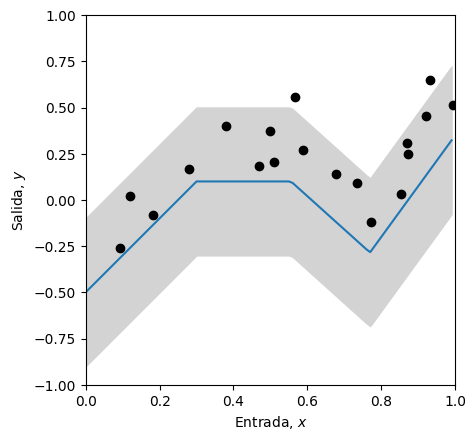

In [5]:
# Creemos algunos datos de entrenamiento 1D
x_train = np.array([0.09291784,0.46809093,0.93089486,0.67612654,0.73441752,0.86847339,\
                   0.49873225,0.51083168,0.18343972,0.99380898,0.27840809,0.38028817,\
                   0.12055708,0.56715537,0.92005746,0.77072270,0.85278176,0.05315950,\
                   0.87168699,0.58858043])
y_train = np.array([-0.25934537,0.18195445,0.651270150,0.13921448,0.09366691,0.30567674,\
                    0.372291170,0.20716968,-0.08131792,0.51187806,0.16943738,0.3994327,\
                    0.019062570,0.55820410,0.452564960,-0.1183121,0.02957665,-1.24354444, \
                    0.248038840,0.26824970])

# Obtener parámetros para el modelo
beta_0, omega_0, beta_1, omega_1 = get_parameters()
sigma = 0.2

# Definir un rango de valores de entrada
x_model = np.arange(0,1,0.01)
# Ejecutar el modelo para obtener valores a trazar y trazarlos.
y_model = shallow_nn(x_model, beta_0, omega_0, beta_1, omega_1)
plot_univariate_regression(x_model, y_model, x_train, y_train, sigma_model = sigma)

La línea azul es la predicción media del modelo y el área gris representa más/menos dos desviaciones estándar. Este modelo se ajusta bien, pero podría mejorarse. Calculemos la pérdida. Calcularemos el error de mínimos cuadrados, la verosimilitud y la log-verosimilitud negativa.

In [6]:
# Devuelve la probabilidad bajo la distribución normal para la entrada x
def normal_distribution(y, mu, sigma):
    # TO DO: escriba la ecuación para la distribución normal
    # Ecuación 5.7 de las notas (necesitará np.sqrt() y np.exp(), y math.pi)
    # No use la versión de numpy, ¡eso es hacer trampa!
    # Reemplace la línea de abajo
    prob = (1 / np.sqrt(2 * math.pi * sigma**2)) * np.exp(-((y - mu) ** 2) / (2 * sigma**2))

    return prob

In [7]:
# Verifiquemos que obtenemos la respuesta correcta antes de continuar
print("Respuesta correcta = %3.3f, Su respuesta = %3.3f"%(0.119,normal_distribution(1,-1,2.3)))

Respuesta correcta = 0.119, Su respuesta = 0.119


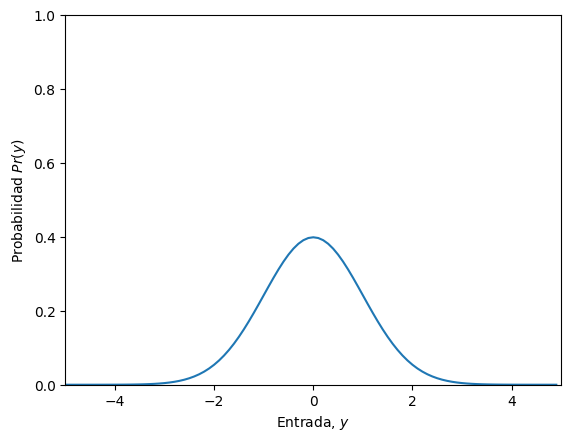

In [8]:
# Trazemos la distribución Gaussiana.
y_gauss = np.arange(-5,5,0.1)
mu = 0; sigma = 1.0
gauss_prob = normal_distribution(y_gauss, mu, sigma)
fig, ax = plt.subplots()
ax.plot(y_gauss, gauss_prob)
ax.set_xlabel('Entrada, $y$'); ax.set_ylabel('Probabilidad $Pr(y)$')
ax.set_xlim([-5,5]);ax.set_ylim([0,1.0])
plt.show()

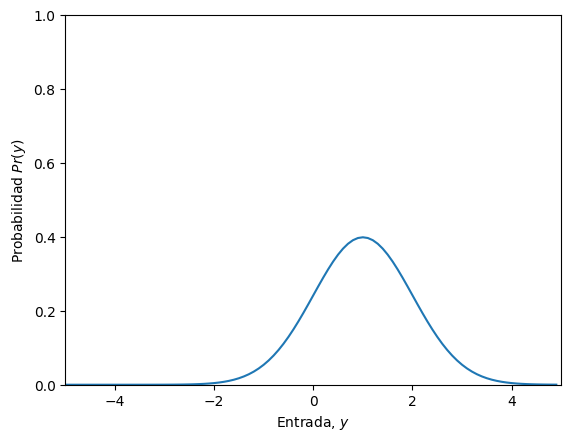

In [9]:
# TO DO
# 1. Prediga qué sucederá si cambiamos a mu=1 y dejamos sigma=1 - la curva se desplazará una unidad a la derecha, sin cambiar su forma.
# Ahora cambie el código de arriba y vea si estaba en lo correcto.
y_gauss = np.arange(-5,5,0.1)
mu = 1; sigma = 1.0
gauss_prob = normal_distribution(y_gauss, mu, sigma)
fig, ax = plt.subplots()
ax.plot(y_gauss, gauss_prob)
ax.set_xlabel('Entrada, $y$'); ax.set_ylabel('Probabilidad $Pr(y)$')
ax.set_xlim([-5,5]);ax.set_ylim([0,1.0])
plt.show()

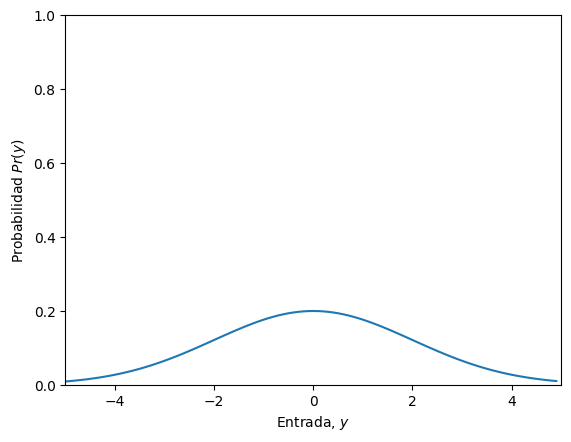

In [10]:
# 2. Prediga qué sucederá si dejamos mu = 0 y cambiamos sigma a 2.0 - la curva se volverá más ancha y baja
y_gauss = np.arange(-5,5,0.1)
mu = 0; sigma = 2.0
gauss_prob = normal_distribution(y_gauss, mu, sigma)
fig, ax = plt.subplots()
ax.plot(y_gauss, gauss_prob)
ax.set_xlabel('Entrada, $y$'); ax.set_ylabel('Probabilidad $Pr(y)$')
ax.set_xlim([-5,5]);ax.set_ylim([0,1.0])
plt.show()

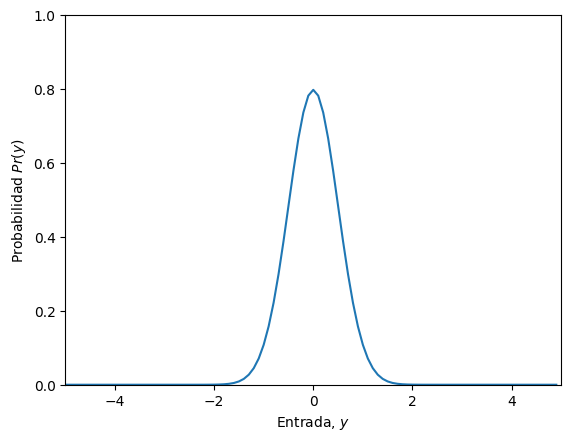

In [11]:
# 3. Prediga qué sucederá si dejamos mu = 0 y cambiamos sigma a 0.5 - la curva se volverá más estrecha y alta
y_gauss = np.arange(-5,5,0.1)
mu = 0; sigma = 0.5
gauss_prob = normal_distribution(y_gauss, mu, sigma)
fig, ax = plt.subplots()
ax.plot(y_gauss, gauss_prob)
ax.set_xlabel('Entrada, $y$'); ax.set_ylabel('Probabilidad $Pr(y)$')
ax.set_xlim([-5,5]);ax.set_ylim([0,1.0])
plt.show()

Ahora calculemos la verosimilitud usando esta función

In [12]:
# Devuelve la verosimilitud de todos los datos bajo el modelo
def compute_likelihood(y_train, mu, sigma):
  # TO DO: calcule la verosimilitud de los datos, el producto de las probabilidades normales para cada punto de datos
  # Línea superior de la ecuación 5.3 en las notas
  # Necesitará np.prod() y la función normal_distribution que usó anteriormente
  # Reemplace la línea de abajo
  likelihood = np.prod(normal_distribution(y_train, mu, sigma))

  return likelihood

In [13]:
# Probemos esto para un modelo homoscedástico (sigma constante)
beta_0, omega_0, beta_1, omega_1 = get_parameters()
# Usamos nuestra red neuronal para predecir la media de la Gaussiana
mu_pred = shallow_nn(x_train, beta_0, omega_0, beta_1, omega_1)
# Establecemos la desviación estándar a algo razonable
sigma = 0.2
# Calculamos la verosimilitud
likelihood = compute_likelihood(y_train, mu_pred, sigma)
# Verifiquemos que obtenemos la respuesta correcta antes de continuar
print("Respuesta correcta = %9.9f, Su respuesta = %9.9f"%(0.000010624,likelihood))

Respuesta correcta = 0.000010624, Su respuesta = 0.000010624


Puede ver que esto da una respuesta muy pequeña, incluso para este pequeño conjunto de datos 1D, y con el modelo ajustándose bastante bien. Esto se debe a que es el producto de varias probabilidades, que son todas bastante pequeñas. Esto se saldrá de control bastante rápido con conjuntos de datos reales: la verosimilitud será tan pequeña que no podremos representarla con la matemática de precisión finita normal.

Por eso usamos la log-verosimilitud negativa

In [14]:
# Devuelve la log-verosimilitud negativa de los datos bajo el modelo
def compute_negative_log_likelihood(y_train, mu, sigma):
  # TO DO: calcule la verosimilitud de los datos; no use la función de verosimilitud anterior; calcule la suma negativa de las probabilidades logarítmicas
  # Ecuación 5.4 en las notas
  # Necesitará np.sum(), np.log()
  # Reemplace la línea de abajo
  nll = -np.sum(np.log(normal_distribution(y_train, mu, sigma)))

  return nll

In [15]:
# Probemos esto para un modelo homoscedástico (sigma constante)
beta_0, omega_0, beta_1, omega_1 = get_parameters()
# Usamos nuestra red neuronal para predecir la media de la Gaussiana
mu_pred = shallow_nn(x_train, beta_0, omega_0, beta_1, omega_1)
# Establecemos la desviación estándar a algo razonable
sigma = 0.2
# Calculamos la log-verosimilitud
nll = compute_negative_log_likelihood(y_train, mu_pred, sigma)
# Verifiquemos que obtenemos la respuesta correcta antes de continuar
print("Respuesta correcta = %9.9f, Su respuesta = %9.9f"%(11.452419564,nll))

Respuesta correcta = 11.452419564, Su respuesta = 11.452419564


Para una buena medida, calculemos también la suma de cuadrados

In [16]:
# Devuelve la distancia cuadrada entre lo predicho
def compute_sum_of_squares(y_train, y_pred):
  # TO DO: calcule la suma de las distancias cuadradas entre los datos de entrenamiento y la predicción del modelo
  # Ecuación 5.10 en las notas. Asegúrese de entender esto y haga preguntas si no lo hace
  # Reemplace la línea de abajo
  sum_of_squares = np.sum((y_train - y_pred) ** 2);

  return sum_of_squares

In [17]:
# Probemos esto de nuevo
beta_0, omega_0, beta_1, omega_1 = get_parameters()
# Usamos nuestra red neuronal para predecir la media de la Gaussiana
y_pred = shallow_nn(x_train, beta_0, omega_0, beta_1, omega_1)
# Calculamos la log-verosimilitud
sum_of_squares = compute_sum_of_squares(y_train, y_pred)
# Verifiquemos que obtenemos la respuesta correcta antes de continuar
print("Respuesta correcta = %9.9f, Su respuesta = %9.9f"%(2.020992572,sum_of_squares))

Respuesta correcta = 2.020992572, Su respuesta = 2.020992572


Ahora investiguemos cómo encontrar la solución de máxima verosimilitud / mínima log-verosimilitud negativa / mínimos cuadrados. Para simplificar, asumiremos que todos los parámetros son correctos excepto uno y veremos cómo cambian la verosimilitud, la log-verosimilitud y la suma de cuadrados a medida que manipulamos el último parámetro. Comenzaremos con el desplazamiento y general, beta_1 (anteriormente phi_0)

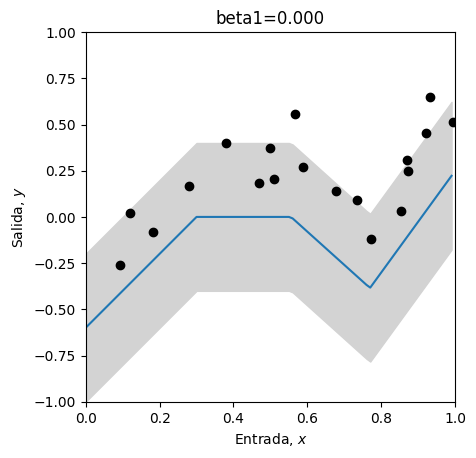

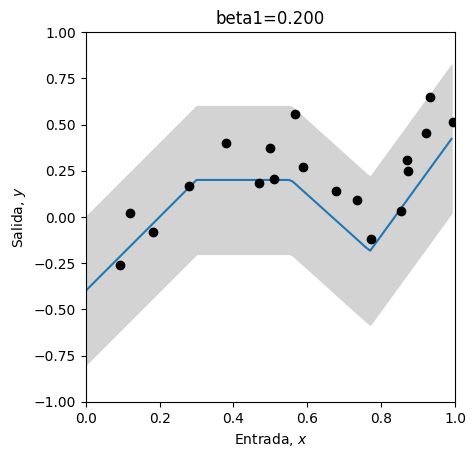

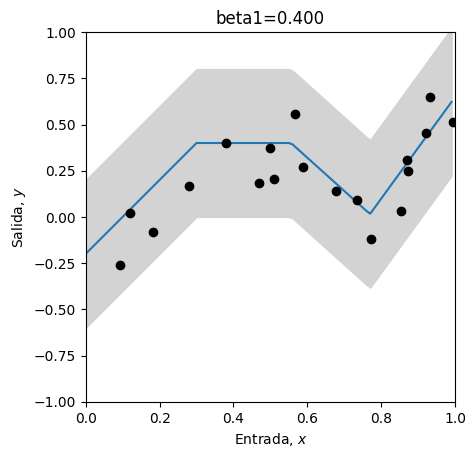

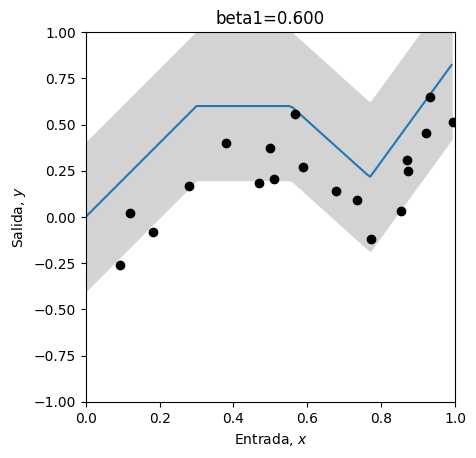

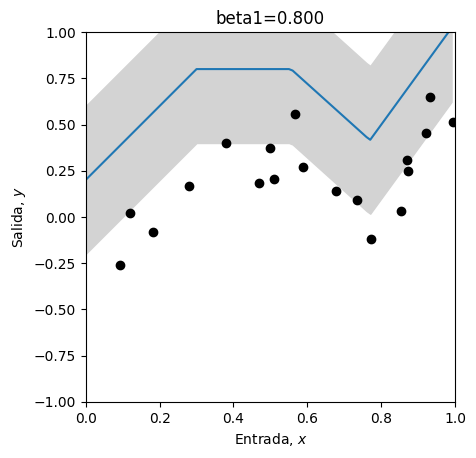

In [18]:
# Definir un rango de valores para el parámetro
beta_1_vals = np.arange(0,1.0,0.01)
# Crear algunos arreglos para almacenar las verosimilitudes, log-verosimilitudes negativas y sumas de cuadrados
likelihoods = np.zeros_like(beta_1_vals)
nlls = np.zeros_like(beta_1_vals)
sum_squares = np.zeros_like(beta_1_vals)

# Inicializar los parámetros
beta_0, omega_0, beta_1, omega_1 = get_parameters()
sigma = 0.2
for count in range(len(beta_1_vals)):
  # Establecer el valor para el parámetro
  beta_1[0,0] = beta_1_vals[count]
  # Ejecutar la red con nuevos parámetros
  mu_pred = y_pred = shallow_nn(x_train, beta_0, omega_0, beta_1, omega_1)
  # Calcular y almacenar los tres valores
  likelihoods[count] = compute_likelihood(y_train, mu_pred, sigma)
  nlls[count] = compute_negative_log_likelihood(y_train, mu_pred, sigma)
  sum_squares[count] = compute_sum_of_squares(y_train, y_pred)
  # Dibujar el modelo para cada 20ª configuración de parámetro
  if count % 20 == 0:
    # Ejecutar el modelo para obtener valores a trazar y trazarlos.
    y_model = shallow_nn(x_model, beta_0, omega_0, beta_1, omega_1)
    plot_univariate_regression(x_model, y_model, x_train, y_train, sigma_model = sigma, title="beta1=%3.3f"%(beta_1[0,0]))

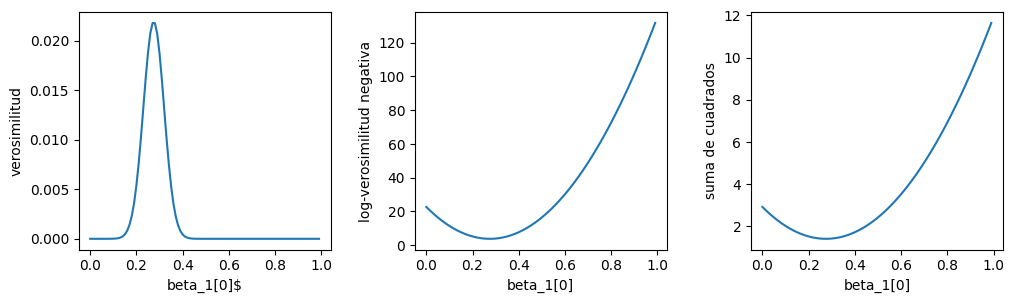

In [19]:
# Ahora tracemos la verosimilitud, la log-verosimilitud negativa y los mínimos cuadrados en función del valor del desplazamiento beta1
fig, ax = plt.subplots(1,3)
fig.set_size_inches(10.5, 3.5)
fig.tight_layout(pad=3.0)
ax[0].plot(beta_1_vals, likelihoods); ax[0].set_xlabel('beta_1[0]$'); ax[0].set_ylabel('verosimilitud')
ax[1].plot(beta_1_vals, nlls); ax[1].set_xlabel('beta_1[0]'); ax[1].set_ylabel('log-verosimilitud negativa')
ax[2].plot(beta_1_vals, sum_squares); ax[2].set_xlabel('beta_1[0]'); ax[2].set_ylabel('suma de cuadrados')
plt.show()

Máxima verosimilitud = 0.022, en beta_1=0.270
Mínima log-verosimilitud negativa = 3.826, en beta_1=0.270
Mínimos cuadrados = 1.411, en beta_1=0.270


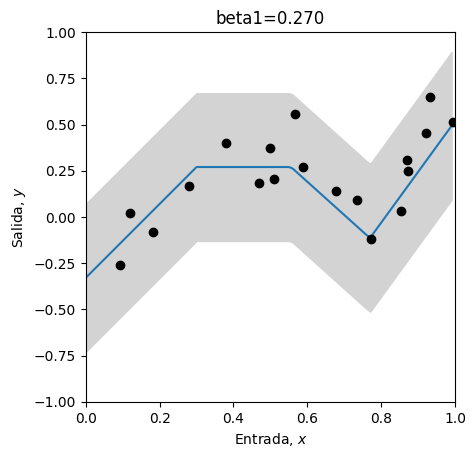

In [20]:
# Esperemos que pueda ver que el máximo de la función de verosimilitud está en la misma posición que la mínima log-verosimilitud negativa
# y las soluciones de mínimos cuadrados
# Comprobemos eso:
print("Máxima verosimilitud = %3.3f, en beta_1=%3.3f"%( (likelihoods[np.argmax(likelihoods)],beta_1_vals[np.argmax(likelihoods)])))
print("Mínima log-verosimilitud negativa = %3.3f, en beta_1=%3.3f"%( (nlls[np.argmin(nlls)],beta_1_vals[np.argmin(nlls)])))
print("Mínimos cuadrados = %3.3f, en beta_1=%3.3f"%( (sum_squares[np.argmin(sum_squares)],beta_1_vals[np.argmin(sum_squares)])))

# Trazar el mejor modelo
beta_1[0,0] = beta_1_vals[np.argmin(sum_squares)]
y_model = shallow_nn(x_model, beta_0, omega_0, beta_1, omega_1)
plot_univariate_regression(x_model, y_model, x_train, y_train, sigma_model = sigma, title="beta1=%3.3f"%(beta_1[0,0]))

Todos dan la misma respuesta. Pero se puede ver en los tres gráficos anteriores que la verosimilitud es muy pequeña a menos que los parámetros sean casi correctos. Así que, en la práctica, trabajaríamos con la log-verosimilitud negativa o los mínimos cuadrados.<br>

Hagamos lo mismo con el parámetro de desviación estándar de nuestra red. Esto no es una salida de la red (a menos que elijamos que lo sea), pero aún así afecta la verosimilitud.

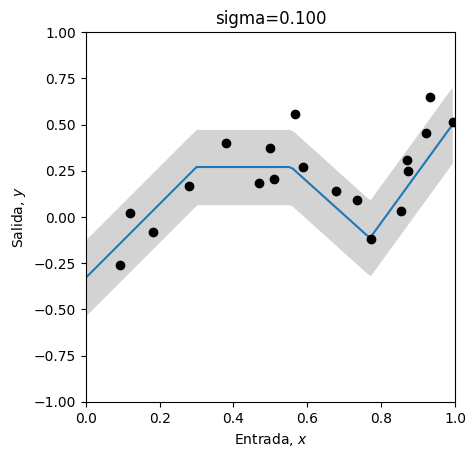

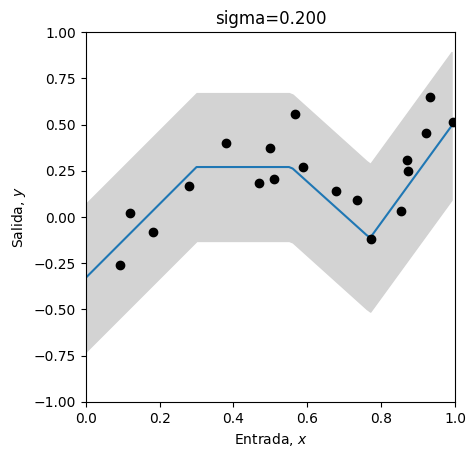

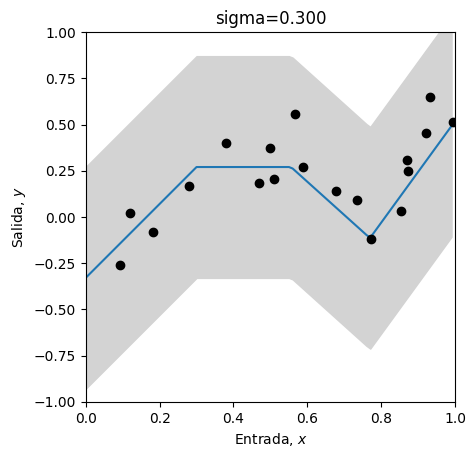

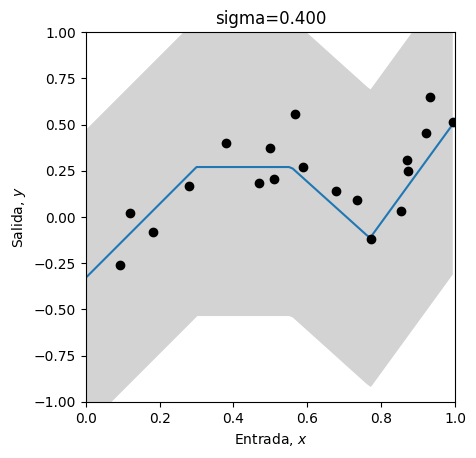

In [21]:
# Definir un rango de valores para el parámetro
sigma_vals = np.arange(0.1,0.5,0.005)
# Crear algunos arreglos para almacenar las verosimilitudes, log-verosimilitudes negativas y sumas de cuadrados
likelihoods = np.zeros_like(sigma_vals)
nlls = np.zeros_like(sigma_vals)
sum_squares = np.zeros_like(sigma_vals)

# Inicializar los parámetros
beta_0, omega_0, beta_1, omega_1 = get_parameters()
# Podríamos establecer el mejor desplazamiento
beta_1[0,0] = 0.27
for count in range(len(sigma_vals)):
  # Establecer el valor para el parámetro
  sigma = sigma_vals[count]
  # Ejecutar la red con nuevos parámetros
  mu_pred = y_pred = shallow_nn(x_train, beta_0, omega_0, beta_1, omega_1)
  # Calcular y almacenar los tres valores
  likelihoods[count] = compute_likelihood(y_train, mu_pred, sigma)
  nlls[count] = compute_negative_log_likelihood(y_train, mu_pred, sigma)
  sum_squares[count] = compute_sum_of_squares(y_train, y_pred)
  # Dibujar el modelo para cada 20ª configuración de parámetro
  if count % 20 == 0:
    # Ejecutar el modelo para obtener valores a trazar y trazarlos.
    y_model = shallow_nn(x_model, beta_0, omega_0, beta_1, omega_1)
    plot_univariate_regression(x_model, y_model, x_train, y_train, sigma_model=sigma, title="sigma=%3.3f"%(sigma))

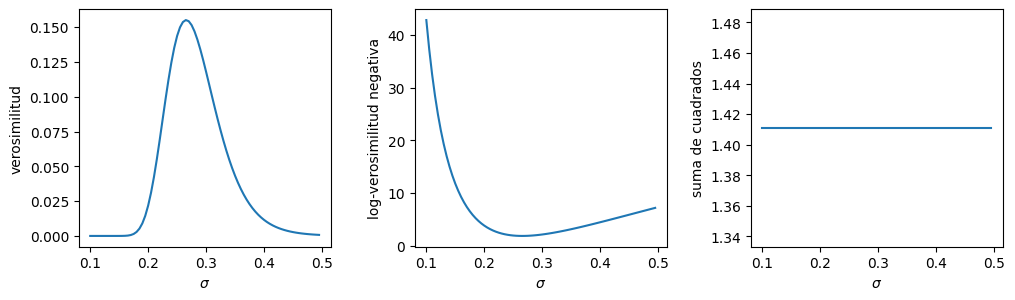

In [22]:
# Ahora tracemos la verosimilitud, la log-verosimilitud negativa y los mínimos cuadrados en función del valor de la desviación estándar sigma
fig, ax = plt.subplots(1,3)
fig.set_size_inches(10.5, 3.5)
fig.tight_layout(pad=3.0)
ax[0].plot(sigma_vals, likelihoods); ax[0].set_xlabel('$\\sigma$'); ax[0].set_ylabel('verosimilitud')
ax[1].plot(sigma_vals, nlls); ax[1].set_xlabel('$\\sigma$'); ax[1].set_ylabel('log-verosimilitud negativa')
ax[2].plot(sigma_vals, sum_squares); ax[2].set_xlabel('$\\sigma$'); ax[2].set_ylabel('suma de cuadrados')
plt.show()

Máxima verosimilitud = 0.155, en beta_1=0.265
Mínima log-verosimilitud negativa = 1.864, en beta_1=0.265


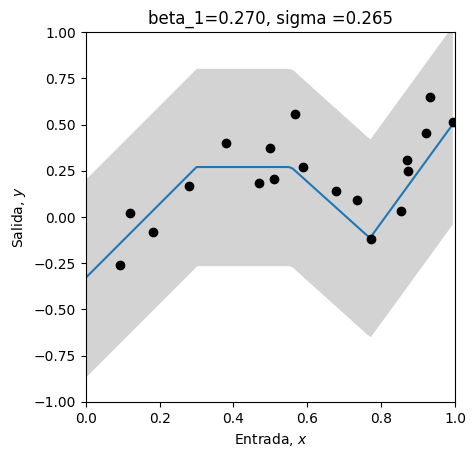

In [23]:
# Esperemos que pueda ver que el máximo de la función de verosimilitud está en la misma posición que la mínima log-verosimilitud negativa
# La solución de mínimos cuadrados no depende de sigma, por lo que es plana, no tiene utilidad aquí.
# Comprobemos eso:
print("Máxima verosimilitud = %3.3f, en beta_1=%3.3f"%( (likelihoods[np.argmax(likelihoods)],sigma_vals[np.argmax(likelihoods)])))
print("Mínima log-verosimilitud negativa = %3.3f, en beta_1=%3.3f"%( (nlls[np.argmin(nlls)],sigma_vals[np.argmin(nlls)])))
# Trazar el mejor modelo
sigma= sigma_vals[np.argmin(nlls)]
y_model = shallow_nn(x_model, beta_0, omega_0, beta_1, omega_1)
plot_univariate_regression(x_model, y_model, x_train, y_train, sigma_model = sigma, title="beta_1=%3.3f, sigma =%3.3f"%(beta_1[0,0],sigma))

Obviamente, para ajustar el modelo neuronal completo, variaríamos todos los 10 parámetros de la red en $\boldsymbol\beta_{0},\boldsymbol\omega_{0},\boldsymbol\beta_{1},\boldsymbol\omega_{1}$ (y quizás $\sigma$) hasta encontrar la combinación que tenga la máxima verosimilitud / mínima log-verosimilitud negativa / mínimos cuadrados.<br><br>

Aquí solo variamos uno a la vez, ya que es más fácil ver lo que sucede. Esto se conoce como **descenso coordinado**.